# Control Results Summary

This notebook loads `results/controls_db.xlsx` and prints compact temporal-control tables for the biggest-backbone models.

For each dataset, model, and probe, the table first selects the best **main-task** layer by test primary metric. Shuffle and single-frame values are then read at that exact same layer. No max is taken over control layers.

- MVP primary metric: pair consistency
- IntPhys2 primary metric: VOE accuracy


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)


def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "results" / "controls_db.xlsx").exists():
            return candidate
    raise FileNotFoundError("Could not find results/controls_db.xlsx from the current directory.")


REPO_ROOT = find_repo_root()
CONTROLS_XLSX = REPO_ROOT / "results" / "controls_db.xlsx"
MAIN_CONFIG_CSV = REPO_ROOT / "results" / "verified_layerwise_probe_configs.csv"
PAPER_TABLE_CSV = REPO_ROOT / "results" / "temporal_controls_main_vs_seed42.csv"

controls = pd.read_excel(CONTROLS_XLSX, sheet_name="controls_db")
main_configs = pd.read_csv(MAIN_CONFIG_CSV)

print(f"controls: {CONTROLS_XLSX}")
print(f"main-task seed42 reference: {MAIN_CONFIG_CSV}")


controls: /gpfs/home2/spunzo1/Probe4Physics/results/controls_db.xlsx
main-task seed42 reference: /gpfs/home2/spunzo1/Probe4Physics/results/verified_layerwise_probe_configs.csv


In [2]:
MODEL_SPECS = [
    {
        "row": "V-JEPA",
        "control_backbone": "jepa_v1",
        "main_experiment": "main",
        "main_model": "V-JEPA",
        "main_backbone": "ViT-H/16",
    },
    {
        "row": "V-JEPA 2",
        "control_backbone": "jepa_v2",
        "main_experiment": "main",
        "main_model": "V-JEPA 2",
        "main_backbone": "ViT-G/16",
    },
    {
        "row": "V-JEPA 2.1",
        "control_backbone": "jepa_v2_1",
        "main_experiment": "main",
        "main_model": "V-JEPA 2.1",
        "main_backbone": "ViT-Gigantic/16",
    },
    {
        "row": "VideoMAE",
        "control_backbone": "videomae",
        "main_experiment": "main",
        "main_model": "VideoMAE",
        "main_backbone": "ViT-H/16",
    },
    {
        "row": "VideoMAE-v2",
        "control_backbone": "videomae_v2",
        "main_experiment": "main",
        "main_model": "VideoMAE-v2",
        "main_backbone": "ViT-G/16",
    },
    {
        "row": "LTX-Video",
        "control_backbone": "ltx_video",
        "main_experiment": "ltx",
        "main_model": "LTX-Video",
        "main_backbone": "LTX-13B",
    },
]

DATASETS = {
    "IntPhys2": {
        "control_dataset": "intphys2",
        "control_metric": "original_voe_accuracy",
    },
    "MVP": {
        "control_dataset": "mvp",
        "control_metric": "original_pair_consistency",
    },
}

PROBES = [("Linear", "linear"), ("MLP", "mlp"), ("Attentive", "temporal_attn")]

LTX_LABEL_TO_SLOT = {
    "noise_0.8_block_24": 17,
    "noise_0.6_block_24": 18,
    "noise_0.5_block_24": 22,
    "noise_0.2_block_24": 34,
    "noise_0.2_block_48": 36,
    "noise_0.1_block_24": 38,
    "noise_0.1_block_36": 39,
}

LTX_SLOT_TO_LABEL = {str(slot): label for label, slot in LTX_LABEL_TO_SLOT.items()}


def format_layer_display(model_spec, layer, layer_label=""):
    normalized_layer = _normalize_layer_value(layer)
    if model_spec.get("main_experiment") != "ltx":
        return normalized_layer or "NA"

    labels = [_normalize_layer_value(layer_label), normalized_layer]
    if normalized_layer in LTX_SLOT_TO_LABEL:
        labels.append(LTX_SLOT_TO_LABEL[normalized_layer])

    for label in labels:
        if label.startswith("noise_") and "_block_" in label:
            noise, block = label.removeprefix("noise_").split("_block_", 1)
            return f"{block} (noise {noise})"
    return normalized_layer or _normalize_layer_value(layer_label) or "NA"


def _numeric_or_nan(value):
    return pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]


def _normalize_layer_value(value):
    if pd.isna(value):
        return ""
    numeric = _numeric_or_nan(value)
    if pd.notna(numeric):
        return str(int(numeric)) if float(numeric).is_integer() else str(float(numeric))
    return str(value).strip()


def _probe_matches(series, probe_label, probe_slug):
    values = series.astype(str).str.lower()
    targets = {probe_label.lower(), probe_slug.lower()}
    if probe_slug == "temporal_attn":
        targets.update({"attentive", "temporal attention", "temporal_attn"})
    return values.isin(targets)


def _layer_candidates(layer_value="", layer_label=""):
    candidates = set()
    for value in (layer_value, layer_label):
        normalized = _normalize_layer_value(value)
        if not normalized:
            continue
        candidates.add(normalized)
        numeric = _numeric_or_nan(normalized)
        if pd.notna(numeric):
            as_int = int(numeric) if float(numeric).is_integer() else float(numeric)
            candidates.add(str(as_int))
            candidates.add(f"L{as_int}")
        mapped = LTX_LABEL_TO_SLOT.get(normalized)
        if mapped is not None:
            candidates.update({str(mapped), f"L{mapped}", normalized})
    return {str(candidate) for candidate in candidates if str(candidate)}


def _main_subset(model_spec, dataset_name, probe_label, probe_slug):
    subset = main_configs[
        (main_configs["dataset"].astype(str) == dataset_name)
        & (main_configs["experiment"].astype(str) == model_spec["main_experiment"])
        & (main_configs["model"].astype(str) == model_spec["main_model"])
        & (main_configs["backbone"].astype(str) == model_spec["main_backbone"])
        & _probe_matches(main_configs["probe_name"], probe_label, probe_slug)
    ].copy()
    return subset


def best_main_row(model_spec, dataset_name, probe_label, probe_slug):
    subset = _main_subset(model_spec, dataset_name, probe_label, probe_slug)
    if subset.empty:
        return {"main": np.nan, "layer": "", "layer_label": "", "main_layer_raw": "", "source_status": "missing main"}

    subset["_metric"] = pd.to_numeric(subset["test_primary_metric"], errors="coerce")
    subset = subset.dropna(subset=["_metric"])
    if subset.empty:
        return {"main": np.nan, "layer": "", "layer_label": "", "main_layer_raw": "", "source_status": "missing metric"}

    row = subset.sort_values("_metric", ascending=False, kind="stable").iloc[0]
    layer_raw = row.get("selected_slot", "")
    for column in ("probe_layer", "excel_layer"):
        if _normalize_layer_value(layer_raw):
            break
        layer_raw = row.get(column, "")
    layer_label = row.get("layer_label", "")
    if not _normalize_layer_value(layer_label):
        layer_label = row.get("excel_layer", "")

    candidates = _layer_candidates(layer_raw, layer_label)
    numeric_candidates = []
    for candidate in candidates:
        if candidate.startswith("L"):
            candidate = candidate[1:]
        numeric = _numeric_or_nan(candidate)
        if pd.notna(numeric) and float(numeric).is_integer():
            numeric_candidates.append(int(numeric))
    layer = numeric_candidates[0] if numeric_candidates else None

    normalized_label = _normalize_layer_value(layer_label) or _normalize_layer_value(layer_raw)
    return {
        "main": float(row["_metric"]),
        "layer": "" if layer is None else int(layer),
        "layer_label": normalized_label,
        "main_layer_raw": _normalize_layer_value(layer_raw),
        "source_status": _normalize_layer_value(row.get("config_status", "")),
        "display_layer": format_layer_display(model_spec, layer, normalized_label),
    }


def control_value(model_spec, dataset_name, probe_slug, control_name, selected):
    cfg = DATASETS[dataset_name]
    target_candidates = _layer_candidates(selected.get("layer", ""), selected.get("layer_label", ""))
    target_candidates |= _layer_candidates(selected.get("main_layer_raw", ""), "")
    if not target_candidates:
        return np.nan

    subset = controls[
        (controls["dataset"].astype(str) == cfg["control_dataset"])
        & (controls["control"].astype(str) == control_name)
        & (controls["backbone"].astype(str) == model_spec["control_backbone"])
        & (controls["probe"].astype(str) == probe_slug)
    ].copy()
    if subset.empty:
        return np.nan

    def matches_selected(row):
        row_candidates = _layer_candidates(row.get("layer", ""), row.get("layer_label", ""))
        return bool(target_candidates & row_candidates)

    matched = subset[subset.apply(matches_selected, axis=1)]
    if matched.empty:
        return np.nan

    metric = cfg["control_metric"]
    values = pd.to_numeric(matched[metric], errors="coerce").dropna()
    return float(values.iloc[0]) if not values.empty else np.nan


def make_absolute_table():
    rows = {}
    selected_rows = []
    for model_spec in MODEL_SPECS:
        model_name = model_spec["row"]
        row = {}
        for dataset_name in DATASETS:
            for probe_label, probe_slug in PROBES:
                selected = best_main_row(model_spec, dataset_name, probe_label, probe_slug)
                main_value = selected["main"]
                shuffle_value = control_value(model_spec, dataset_name, probe_slug, "frame_shuffling", selected)
                single_value = control_value(model_spec, dataset_name, probe_slug, "single_frame", selected)

                row[(dataset_name, probe_label, "Main")] = main_value
                row[(dataset_name, probe_label, "Shuffle")] = shuffle_value
                row[(dataset_name, probe_label, "Single frame")] = single_value

                selected_layer = selected["layer"]
                selected_rows.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Probe": probe_label,
                    "Layer": selected.get("display_layer", "NA"),
                    "Selected label": selected["layer_label"],
                    "Main seed42 test": main_value,
                    "Frame shuffle available": pd.notna(shuffle_value),
                    "Single frame available": pd.notna(single_value),
                    "Source status": selected.get("source_status", ""),
                })
        rows[model_name] = row

    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.name = "Model"
    table.columns = pd.MultiIndex.from_tuples(table.columns, names=["Dataset", "Probe", "Metric"])
    selected_layers = pd.DataFrame(selected_rows)
    return table, selected_layers


def make_temporal_paper_table(absolute, selected_layers):
    rows = []
    selected_lookup = {
        (row.Dataset, row.Model, row.Probe): row.Layer
        for row in selected_layers.itertuples(index=False)
    }
    for dataset_name in DATASETS:
        for model_spec in MODEL_SPECS:
            model_name = model_spec["row"]
            for probe_label, _ in PROBES:
                main = absolute.loc[model_name, (dataset_name, probe_label, "Main")]
                shuffle = absolute.loc[model_name, (dataset_name, probe_label, "Shuffle")]
                single = absolute.loc[model_name, (dataset_name, probe_label, "Single frame")]
                rows.append({
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Probe": probe_label,
                    "Layer": selected_lookup.get((dataset_name, model_name, probe_label), ""),
                    "Main seed42 test": main,
                    "Frame shuffle test": shuffle,
                    "Frame shuffle drop pp": np.nan if pd.isna(main) or pd.isna(shuffle) else shuffle - main,
                    "Single frame test": single,
                    "Single frame drop pp": np.nan if pd.isna(main) or pd.isna(single) else single - main,
                })
    return pd.DataFrame(rows)


absolute_table, selected_layers = make_absolute_table()
temporal_paper_table = make_temporal_paper_table(absolute_table, selected_layers)
temporal_paper_table.to_csv(PAPER_TABLE_CSV, index=False)
print(f"wrote paper table: {PAPER_TABLE_CSV}")
temporal_paper_table.round(2)


wrote paper table: /gpfs/home2/spunzo1/Probe4Physics/results/temporal_controls_main_vs_seed42.csv


,Dataset,Model,Probe,Layer,Main seed42 test,Frame shuffle test,Frame shuffle drop pp,Single frame test,Single frame drop pp
0,IntPhys2,V-JEPA,Linear,24,50.98,21.57,-29.41,7.84,-43.14
1,IntPhys2,V-JEPA,MLP,32,45.10,19.61,-25.49,17.65,-27.45
2,IntPhys2,V-JEPA,Attentive,16,66.67,39.22,-27.45,15.69,-50.98
3,IntPhys2,V-JEPA 2,Linear,40,41.18,31.37,-9.80,25.49,-15.69
4,IntPhys2,V-JEPA 2,MLP,30,56.86,23.53,-33.33,21.57,-35.29
5,IntPhys2,V-JEPA 2,Attentive,40,78.43,54.90,-23.53,17.65,-60.78
6,IntPhys2,V-JEPA 2.1,Linear,48,35.29,35.29,0.00,9.80,-25.49
7,IntPhys2,V-JEPA 2.1,MLP,38,39.22,29.41,-9.80,19.61,-19.61
8,IntPhys2,V-JEPA 2.1,Attentive,48,60.78,60.78,0.00,15.69,-45.10
9,IntPhys2,VideoMAE,Linear,16,35.29,19.61,-15.69,9.80,-25.49


## Percentage-Point Drop Table

For each control condition, the signed drop from the selected main-task score is:

$$\Delta_{pp}=\text{Control}-\text{Main}$$

Negative values indicate lower control performance at the same main-task-selected layer.


In [3]:
def make_relative_table(absolute):
    rows = {}
    for model_name in absolute.index:
        row = {}
        for dataset_name in DATASETS:
            for probe_label, _ in PROBES:
                main = absolute.loc[model_name, (dataset_name, probe_label, "Main")]
                shuffle = absolute.loc[model_name, (dataset_name, probe_label, "Shuffle")]
                single = absolute.loc[model_name, (dataset_name, probe_label, "Single frame")]
                row[(dataset_name, probe_label, "Main")] = main
                row[(dataset_name, probe_label, "Drop shuffle pp")] = np.nan if pd.isna(main) or pd.isna(shuffle) else shuffle - main
                row[(dataset_name, probe_label, "Drop single frame pp")] = np.nan if pd.isna(main) or pd.isna(single) else single - main
        rows[model_name] = row
    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.name = "Model"
    table.columns = pd.MultiIndex.from_tuples(table.columns, names=["Dataset", "Probe", "Metric"])
    return table


relative_table = make_relative_table(absolute_table)
relative_table.round(2)


Dataset     IntPhys2                                                                                                                                    MVP                                                                                   \
Probe         Linear                                         MLP                                      Attentive                                      Linear                                         MLP                                        
Metric          Main Drop shuffle pp Drop single frame pp   Main Drop shuffle pp Drop single frame pp      Main Drop shuffle pp Drop single frame pp   Main Drop shuffle pp Drop single frame pp   Main Drop shuffle pp Drop single frame pp   
Model                                                                                                                                                                                                                                          
V-JEPA         50.98          -29.41               -43.14  45.10          -25.49               -27.45     66.67          -27.45               -50.98  48.74          -13.95               -43.78  87.26          -48.33               -87.26   
V-JEPA 2       41.18           -9.80               -15.69  56.86          -33.33               -35.29     78.43          -23.53               -60.78  48.53          -17.59               -46.31  86.75          -46.31               -80.99   
V-JEPA 2.1     35.29            0.00               -25.49  39.22           -9.80               -19.61     60.78            0.00               -45.10  42.26          -14.96               -40.55  70.78          -34.78               -65.82   
VideoMAE       35.29          -15.69               -25.49  35.29          -21.57               -21.57     76.47          -23.53               -58.82  37.51           -8.09               -32.56  64.41          -25.28               -59.96   
VideoMAE-v2    47.06          -25.49               -31.37  47.06          -33.33               -35.29     62.75          -15.69               -43.14  37.71           -9.61               -34.88  66.13          -29.22               -63.90   
LTX-Video      49.02          -29.41               -49.02  47.06          -31.37               -25.49     43.14          -25.49               -35.29  50.56          -25.99               -41.25  68.86          -39.53               -57.63   

Dataset                                                     
Probe       Attentive                                       
Metric           Main Drop shuffle pp Drop single frame pp  
Model                                                       
V-JEPA          95.05          -22.95               -84.43  
V-JEPA 2        94.03          -29.63               -72.50  
V-JEPA 2.1      94.94          -13.75               -79.47  
VideoMAE        92.01          -22.24               -75.53  
VideoMAE-v2     91.10          -34.38               -76.44  
LTX-Video       84.33          -80.89               -81.40

## Copy Drop Table LaTeX

Use this button to copy the percentage-point drop table in the paper format, using the values currently loaded in this notebook.


In [4]:
from IPython.display import HTML, display
import html
import json
import uuid

LATEX_DATASETS = [("IntPhys2", "(a) IntPhys2"), ("MVP", "(b) MVP")]
LATEX_PROBES = [("Linear", "Linear"), ("MLP", "MLP"), ("Attentive", "Temporal Attn.")]
LATEX_METRICS = ["Main", "Drop shuffle pp", "Drop single frame pp"]
LATEX_MODELS = [model_spec["row"] for model_spec in MODEL_SPECS]
LATEX_ROW_END = r"\\"


def _latex_number(value):
    if pd.isna(value):
        return "--"
    return f"{float(value):.2f}"


def _latex_bold_cells(table):
    cells = set()
    for dataset_name, _ in LATEX_DATASETS:
        for probe_label, _ in LATEX_PROBES:
            for metric in ("Drop shuffle pp", "Drop single frame pp"):
                values = pd.to_numeric(table.loc[:, (dataset_name, probe_label, metric)], errors="coerce")
                strongest_drop = values.min()
                if pd.isna(strongest_drop):
                    continue
                for model_name in values.index[values == strongest_drop]:
                    cells.add((dataset_name, model_name, probe_label, metric))
    return cells


def _latex_cell(table, dataset_name, model_name, probe_label, metric, bold_cells):
    value = _latex_number(table.loc[model_name, (dataset_name, probe_label, metric)])
    if (dataset_name, model_name, probe_label, metric) in bold_cells:
        return f"\\textbf{{{value}}}"
    return value


def make_drop_table_latex(table):
    bold_cells = _latex_bold_cells(table)
    lines = [
        r"\begin{table*}[t]",
        r"\centering",
        r"\small",
        r"\setlength{\tabcolsep}{5pt}",
        r"\renewcommand{\arraystretch}{1.05}",
        "",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{lccc ccc ccc}",
        r"\toprule",
        r"\textbf{Model}",
        r"& \multicolumn{3}{c}{\textbf{Linear}}",
        r"& \multicolumn{3}{c}{\textbf{MLP}}",
        r"& \multicolumn{3}{c}{\textbf{Temporal Attn.}} " + LATEX_ROW_END,
        r"\cmidrule(lr){2-4}",
        r"\cmidrule(lr){5-7}",
        r"\cmidrule(lr){8-10}",
        r"& \textbf{Main} & \makecell{\textbf{$\Delta\!\downarrow$ shuffle}\\\textbf{(pp)}} & \makecell{\textbf{$\Delta\!\downarrow$ single}\\\textbf{(pp)}}",
        r"& \textbf{Main} & \makecell{\textbf{$\Delta\!\downarrow$ shuffle}\\\textbf{(pp)}} & \makecell{\textbf{$\Delta\!\downarrow$ single}\\\textbf{(pp)}}",
        r"& \textbf{Main} & \makecell{\textbf{$\Delta\!\downarrow$ shuffle}\\\textbf{(pp)}} & \makecell{\textbf{$\Delta\!\downarrow$ single}\\\textbf{(pp)}} " + LATEX_ROW_END,
        r"\midrule",
    ]

    for dataset_name, dataset_title in LATEX_DATASETS:
        lines.extend([
            rf"\multicolumn{{10}}{{c}}{{\textbf{{{dataset_title}}}}} " + LATEX_ROW_END,
            r"\midrule",
            "",
        ])
        for model_name in LATEX_MODELS:
            values = []
            for probe_label, _ in LATEX_PROBES:
                for metric in LATEX_METRICS:
                    values.append(_latex_cell(table, dataset_name, model_name, probe_label, metric, bold_cells))
            lines.append(f"{model_name:<12} & " + " & ".join(values) + f" {LATEX_ROW_END}")
        if dataset_name != LATEX_DATASETS[-1][0]:
            lines.extend(["", r"\midrule"])

    lines.extend([
        "",
        r"\bottomrule",
        r"\end{tabular}%",
        r"}",
        "",
        r"\vspace{0.4em}",
        r"\caption{",
        r"Temporal-control results for Experiment~4. Main denotes VOE accuracy for IntPhys2 and pair consistency for MVP. Control columns report signed percentage-point change, computed as $\Delta_{pp}=\text{Control}-\text{Main}$. More negative values indicate stronger degradation under temporal disruption; bold marks the strongest degradation within each dataset, probe type, and control.",
        r"}",
        r"\label{tab:exp4-temporal-controls}",
        r"\end{table*}",
    ])
    return "\n".join(lines)


drop_table_latex = make_drop_table_latex(relative_table)
button_id = f"copy-latex-{uuid.uuid4().hex}"
status_id = f"copy-status-{uuid.uuid4().hex}"
textarea_id = f"latex-text-{uuid.uuid4().hex}"
latex_json = json.dumps(drop_table_latex)

display(HTML(f"""
<div style="margin: 0.5rem 0 1rem 0;">
  <button id="{button_id}" style="padding: 6px 10px; cursor: pointer;">Copy LaTeX table</button>
  <span id="{status_id}" style="margin-left: 8px;"></span>
  <details style="margin-top: 8px;">
    <summary>Show generated LaTeX</summary>
    <textarea id="{textarea_id}" readonly style="width: 100%; height: 360px; margin-top: 8px; font-family: ui-monospace, SFMono-Regular, Menlo, Monaco, Consolas, monospace; font-size: 12px;">{html.escape(drop_table_latex)}</textarea>
  </details>
</div>
<script>
(() => {{
  const text = {latex_json};
  const button = document.getElementById("{button_id}");
  const status = document.getElementById("{status_id}");
  const textarea = document.getElementById("{textarea_id}");
  button.addEventListener("click", async () => {{
    try {{
      if (navigator.clipboard && window.isSecureContext) {{
        await navigator.clipboard.writeText(text);
      }} else {{
        textarea.focus();
        textarea.select();
        document.execCommand("copy");
      }}
      status.textContent = "Copied.";
    }} catch (error) {{
      status.textContent = "Copy failed; select the text below.";
    }}
  }});
}})();
</script>
"""))


## Selected Main Layers

This table is included as an audit trail: every control value above is read at the selected main-task layer shown here.

In [5]:
selected_layers


,Dataset,Model,Probe,Layer,Selected label,Main seed42 test,Frame shuffle available,Single frame available,Source status
0,IntPhys2,V-JEPA,Linear,24,Layer 0.75,50.980392,True,True,VERIFIED_FULL
1,IntPhys2,V-JEPA,MLP,32,Final layer,45.098039,True,True,VERIFIED_FULL
2,IntPhys2,V-JEPA,Attentive,16,16,66.666667,True,True,VERIFIED_FULL
3,MVP,V-JEPA,Linear,32,Final layer,48.736097,True,True,VERIFIED_FULL
4,MVP,V-JEPA,MLP,32,Final layer,87.259858,True,True,VERIFIED_FULL
5,MVP,V-JEPA,Attentive,24,Layer 0.75,95.045501,True,True,VERIFIED_FULL
6,IntPhys2,V-JEPA 2,Linear,40,Final layer,41.176471,True,True,VERIFIED_FULL
7,IntPhys2,V-JEPA 2,MLP,30,Layer 0.75,56.862745,True,True,VERIFIED_FULL
8,IntPhys2,V-JEPA 2,Attentive,40,40,78.431373,True,True,VERIFIED_FULL
9,MVP,V-JEPA 2,Linear,40,Final layer,48.533873,True,True,VERIFIED_FULL


In [6]:
missing = int(absolute_table.isna().sum().sum() + relative_table.isna().sum().sum())
if missing:
    print(f"Warning: found {missing} missing table entries. Check selected_layers and control layer coverage.")
else:
    print("All requested table entries were found.")


All requested table entries were found.


## Control Drop Plot


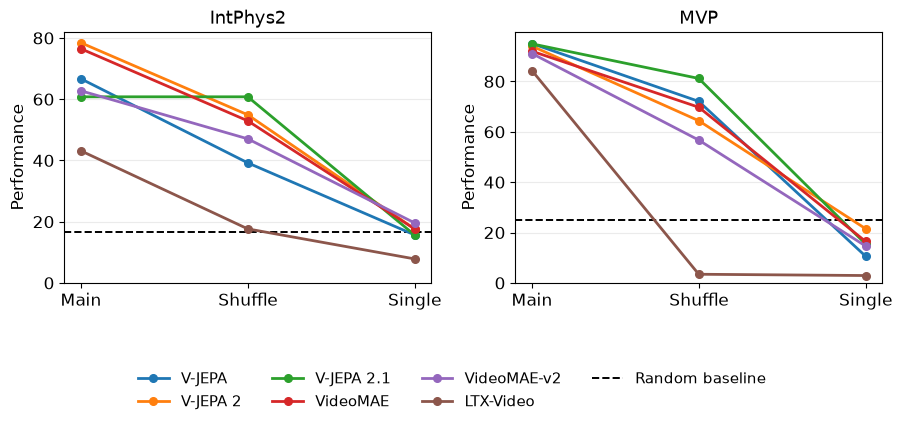

In [7]:
import os

mpl_config_dir = Path("/tmp") / "probe4physics-matplotlib"
mpl_config_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_config_dir))

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
})

PLOT_PROBE = "Attentive"
RANDOM_BASELINES = {
    "MVP": 25.0,
    "IntPhys2": 100.0 / 6.0,
}
plot_metrics = ["Main", "Shuffle", "Single frame"]
plot_tick_labels = ["Main", "Shuffle", "Single"]
x = np.arange(len(plot_metrics))

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0), sharey=False)

for ax, dataset_name in zip(axes, DATASETS):
    for model_name in absolute_table.index:
        y = [absolute_table.loc[model_name, (dataset_name, PLOT_PROBE, metric)] for metric in plot_metrics]
        ax.plot(x, y, marker="o", linewidth=2.0, markersize=5.5, label=model_name)
    ax.axhline(RANDOM_BASELINES[dataset_name], color="black", linestyle="--", linewidth=1.4, label="Random baseline", zorder=0)

    ax.set_title(dataset_name)
    ax.set_xticks(x, plot_tick_labels)
    ax.set_ylabel("Performance")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0.16, 1, 1))
plt.show()
